<a href="https://colab.research.google.com/github/anaslukman03/AmazonEarphonePriceAnalytics/blob/main/amazonEarphoneAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install libraries
!pip install requests beautifulsoup4 pandas lxml
!pip install selenium webdriver-manager


In [ ]:
#import libraries
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import random

In [ ]:
#extracting attributes

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept-Language": "en-US,en;q=0.9",
}

BASE_URL = "https://www.amazon.com/s"
SEARCH_QUERY = "wireless earphones"
PAGES_TO_SCRAPE = 7

all_items = []

for page in range(1, PAGES_TO_SCRAPE + 1):
    params = {"k": SEARCH_QUERY, "page": page}
    response = requests.get(BASE_URL, params=params, headers=headers)
    print("Page", page, "status:", response.status_code)

    soup = BeautifulSoup(response.text, "html.parser")
    results = soup.find_all("div", {"data-component-type": "s-search-result"})

    print("  Products found this page:", len(results))

    for item in results:
        #product name
        name_tag = item.h2
        name = name_tag.text.strip() if name_tag else None

        #display price
        price_whole = item.find("span", class_="a-price-whole")
        price_fraction = item.find("span", class_="a-price-fraction")

        if price_whole and price_fraction:
            price_number = price_whole.text.replace(",", "").strip() + "." + price_fraction.text.strip()
            price_display = f"${price_number}"
        else:
            price_display = None

        #original price (strike-through)
        original_price = "N/A"
        strike = item.find("span", class_="a-price a-text-price")
        if strike:
            price_tag = strike.find("span", class_="a-offscreen")
            if price_tag:
                original_price = price_tag.text.strip()

        # BRAND (most reliable Amazon pattern)
        brand = "N/A"

        # 1. Pattern: Amazon’s dedicated brand tag
        brand_tag = item.find("h5", class_="s-line-clamp-1")
        if brand_tag:
            brand = brand_tag.text.strip()

        # 2. Fallback tag (Amazon sometimes uses this)
        if brand == "N/A":
            tag2 = item.find("span", class_="a-size-base-plus a-color-base")
            if tag2:
                brand = tag2.text.strip()

        # 3. FINAL FALLBACK → First word of product title
        if brand == "N/A" and name:
            first_word = name.split()[0].strip()

            # List of words that are NOT brands
            generic_words = {
                "Wireless", "Wired", "Bluetooth", "Gaming", "Mouse",
                "RGB", "2.4G", "2.4GHz", "Ergonomic", "USB", "Rechargeable"
            }

            if first_word not in generic_words:
                brand = first_word

        #extracting rating
        rating_tag = item.find("span", class_="a-icon-alt")
        rating = rating_tag.text.strip() if rating_tag else "N/A"

        # Extract Number of Reviews
        reviews_tag = item.find("span", class_="a-size-base")
        reviews = reviews_tag.text.strip() if reviews_tag else "N/A"

        # PRODUCT URL
        link_tag = item.find("a", class_="a-link-normal", href=True)
        if link_tag:
            url = "https://www.amazon.com" + link_tag["href"]
        else:
            url = None

        # DELIVERY INFO
        delivery_tag = (
            item.select_one("span.a-text-bold") or  # older version
            item.select_one("span.a-size-base.a-color-secondary")  # newer version
        )
        delivery = delivery_tag.get_text(strip=True) if delivery_tag else None

        all_items.append({
            "Product name": name,
            "Price ($)": price_display,
            "Original Price": original_price,
            "Brand": brand,
            "Rating": rating,
            "Number of Reviews": reviews,
            "Delivery Info": delivery,
            "Product URL": url
        })

raw_df = pd.DataFrame(all_items)
print("Total products scraped:", len(raw_df))




Page 1 status: 200
  Products found this page: 16
Page 2 status: 200
  Products found this page: 22
Page 3 status: 200
  Products found this page: 16
Page 4 status: 200
  Products found this page: 16
Page 5 status: 200
  Products found this page: 16
Page 6 status: 200
  Products found this page: 16
Page 7 status: 200
  Products found this page: 16
Total products scraped: 118


In [ ]:
#scraped attributes


product_names = []
product_prices = []
original_prices = []
brands = []
ratings_cleaned = []
reviews_list = []
deliveries = []
urls = []


for page in range(1, PAGES_TO_SCRAPE + 1):
    params = {"k": SEARCH_QUERY, "page": page}
    response = requests.get(BASE_URL, params=params, headers=headers)
    print(f"Page {page} status code:", response.status_code)

    soup = BeautifulSoup(response.text, "html.parser")

    # Each product result is usually inside a div with this attribute
    results = soup.find_all("div", {"data-component-type": "s-search-result"})
    print(f"  Products found on page {page}: {len(results)}")

    for item in results:
        # Product name
        name_tag = item.h2
        name = name_tag.text.strip() if name_tag else None

        # Product price (sometimes split into whole + fraction)
        price_whole = item.find("span", class_="a-price-whole")
        price_fraction = item.find("span", class_="a-price-fraction")

        #original price (strike-through)
        original_price = "N/A"
        strike = item.find("span", class_="a-price a-text-price")
        if strike:
            price_tag = strike.find("span", class_="a-offscreen")
            if price_tag:
                original_price = price_tag.text.strip()

        # BRAND (most reliable Amazon pattern)
        brand = "N/A"

        # 1. Pattern: Amazon’s dedicated brand tag
        brand_tag = item.find("h5", class_="s-line-clamp-1")
        if brand_tag:
            brand = brand_tag.text.strip()

        # 2. Fallback tag (Amazon sometimes uses this)
        if brand == "N/A":
            tag2 = item.find("span", class_="a-size-base-plus a-color-base")
            if tag2:
                brand = tag2.text.strip()

        # 3. FINAL FALLBACK → First word of product title
        if brand == "N/A" and name:
            first_word = name.split()[0].strip()

            # List of words that are NOT brands
            generic_words = {
                "Wireless", "Wired", "Bluetooth", "Gaming", "Mouse",
                "RGB", "2.4G", "2.4GHz", "Ergonomic", "USB", "Rechargeable"
            }

            if first_word not in generic_words:
                brand = first_word

        #extracting rating
        rating_tag = item.find("span", class_="a-icon-alt")
        rating = rating_tag.text.strip() if rating_tag else "N/A"

        # Extract Number of Reviews
        reviews_tag = item.find("span", class_="a-size-base")
        reviews = reviews_tag.text.strip() if reviews_tag else "N/A"

        # PRODUCT URL
        link_tag = item.find("a", class_="a-link-normal", href=True)
        if link_tag:
            url = "https://www.amazon.com" + link_tag["href"]
        else:
            url = None

        # DELIVERY INFO
        delivery_tag = (
            item.select_one("span.a-text-bold") or  # older version
            item.select_one("span.a-size-base.a-color-secondary")  # newer version
        )
        delivery = delivery_tag.get_text(strip=True) if delivery_tag else None

        # price_display
        if price_whole and price_fraction:
            price_number = (
                price_whole.text.replace(",", "").strip()
                +
                price_fraction.text.strip()
            )
            price_display = f"{price_number}"
        else:
            price_display = "N/A"



        # append safely
        if name:
            product_names.append(name)
            product_prices.append(price_display)
            original_prices.append(original_price)
            brands.append(brand)
            ratings_cleaned.append(rating)
            reviews_list.append(reviews)
            deliveries.append(delivery)
            urls.append(url)


# Create table (DataFrame) with nice headers
raw_df = pd.DataFrame({
    "Product Name": product_names,
    "Price": product_prices,
    "Original Price": original_prices,
    "Brand": brands,
    "Rating": ratings_cleaned,
    "Number of Reviews": reviews_list,
    "Delivery Info": deliveries,
    "Product URL": urls
})

print("Total products scraped:", len(raw_df))
raw_df


Page 1 status code: 200
  Products found on page 1: 16
Page 2 status code: 200
  Products found on page 2: 16
Page 3 status code: 200
  Products found on page 3: 16
Page 4 status code: 200
  Products found on page 4: 16
Page 5 status code: 200
  Products found on page 5: 16
Page 6 status code: 200
  Products found on page 6: 16
Page 7 status code: 200
  Products found on page 7: 22
Total products scraped: 118


,Product Name,Price,Original Price,Brand,Rating,Number of Reviews,Delivery Info,Product URL
0,JBL Vibe Beam - True Wireless JBL Deep Bass So...,29.95,$49.95,JBL,4.2 out of 5 stars,10K+ bought in past month,Jan 11 - 12,https://www.amazon.com/JBL-Vibe-Beam-Wireless-...
1,"Wireless Earbuds, Bluetooth 5.3 Headphones HiF...",16.14,$16.99,N/A,4.9 out of 5 stars,Products highlighted as 'Overall Pick' are:,Amazon's Choice: Overall Pick,https://www.amazon.com/Fhumsh-Bluetooth-Headph...
2,"BUGANI OE03 Open Ear Headphones, Bluetooth 5.3...",79.99,N/A,BUGANI,5.0 out of 5 stars,New on Amazon in past month,"Fri, Jan 9",https://www.amazon.com/BUGANI-OE03-Headphones-...
3,"Wireless Earbuds, Bluetooth 5.4 Headphones Bas...",21.99,$32.99,N/A,4.6 out of 5 stars,10K+ bought in past month,"Fri, Jan 9",https://www.amazon.com/Bluetooth-Headphones-Ca...
4,kurdene Wireless Earbuds Bluetooth 5.3 in Ear ...,9.99,N/A,kurdene,4.3 out of 5 stars,10K+ bought in past month,"Fri, Jan 9",https://www.amazon.com/kurdene-Bluetooth-Light...
...,...,...,...,...,...,...,...,...
113,"JBL Vibe Buds - True Wireless Earbuds, Smart A...",29.95,$49.95,JBL,4.2 out of 5 stars,9K+ bought in past month,"Fri, Jan 9",https://www.amazon.com/JBL-Vibe-Buds-Wireless-...
114,"Wireless Earbuds, 2025 Bluetooth 5.4 Headphone...",9.99,N/A,N/A,4.8 out of 5 stars,1K+ bought in past month,"Fri, Jan 9",https://www.amazon.com/Bluetooth-Headphones-Ca...
115,Wireless Waterproof Sports Earphones with 100 ...,19.99,N/A,N/A,4.2 out of 5 stars,Save 20%,"Fri, Jan 9",https://www.amazon.com/LANDIBO-Waterproof-Earp...
116,"THINKAR SoraClips Open Ear Earbuds, 4.6G Ultra...",24.28,N/A,THINKAR,4.3 out of 5 stars,N/A,"Fri, Jan 9",https://www.amazon.com/sspa/click?ie=UTF8&spc=...


In [ ]:
#cleaning data / handle missing data
import pandas as pd
import numpy as np

# Start from the scraped data
clean_df = raw_df.copy()

#count row before cleaning
print("Rows before removing missing data:", len(raw_df))

# Cleaning 1: Remove rows with missing price
clean_df = clean_df.dropna(subset=["Price"])

#cleaning 2: clean price string and convert to float
clean_df["Price_str"] = (
    clean_df["Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# Convert to numeric safely
clean_df["Price"] = pd.to_numeric(clean_df["Price_str"], errors="coerce")

# Drop any rows where conversion failed
clean_df = clean_df.dropna(subset=["Price"])

# Cleaning 3: Clean product name (keep main name only)
def clean_product_name(text):
    if pd.isna(text):
        return text
    text = str(text).strip()
    # Keep text before common separators
    for sep in [" - ", " | ", ": "]:
        if sep in text:
            text = text.split(sep)[0]
    # Remove extra spaces
    text = " ".join(text.split())
    return text

clean_df["Product Name"] = clean_df["Product Name"].apply(clean_product_name)

# Optional: remove duplicate product names
before_dups = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["Product Name"])

#cleaning 4: clean original price remove currency sign
clean_df["Original Price"] = (
    clean_df["Original Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("RM", "", regex=False)
    .str.replace("EUR", "", regex=False)
    .str.strip()
)

#convert original price str to integer
if clean_df["Original Price"] is not None:
    clean_df["Original Price"] = pd.to_numeric(clean_df["Original Price"], errors="coerce")
else:
    clean_df["Original Price"] = None


# Clean Brand column properly
clean_df["Brand"] = (
    clean_df["Brand"]
    .astype(str)
    .str.strip()
    .str.upper()
)

clean_df["Brand"] = clean_df["Brand"].where(
    ~clean_df["Brand"].str.fullmatch(r"\d+(\.\d+)?"),
    np.nan
)


# Convert placeholder strings to NaN
clean_df["Brand"] = clean_df["Brand"].replace(
    ["N/A", "NA", "NONE", ""],
    np.nan
)

# Drop rows with missing Brand
clean_df = clean_df.dropna(subset=["Brand"])

# Fix: Removed inplace=True when reassigning clean_df
clean_df = clean_df.dropna(subset=["Original Price"], axis=0)

clean_df = clean_df.dropna(subset=["Brand"])


# clean 5: Convert Rating to numeric (float) and handle missing values
clean_df['Rating'] = clean_df['Rating'].str.replace(' out of 5 stars', '', regex=False)
clean_df['Rating'] = pd.to_numeric(clean_df['Rating'], errors='coerce')  # 'N/A' becomes NaN

# clean 6: Convert Number of Reviews to numeric and handle missing values
clean_df['Number of Reviews'] = clean_df['Number of Reviews'].str.replace(',', '', regex=False)
clean_df['Number of Reviews'] = pd.to_numeric(clean_df['Number of Reviews'], errors='coerce')  # 'N/A' becomes NaN

# Optional: replace NaN with 0
clean_df['Rating'] = clean_df['Rating'].fillna(0)
clean_df['Number of Reviews'] = clean_df['Number of Reviews'].fillna(0)

# Cleaning 7: Remove missing Product URLs
clean_df = clean_df.dropna(subset=["Product URL"])

# Cleaning 8: Clean delivery strings

clean_df["Delivery Info"] = (
    clean_df["Delivery Info"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.strip()
)


# Cleaning 9: Remove duplicate URLs

before_dups = len(clean_df)
clean_df = clean_df.drop_duplicates(subset=["Product URL"])

clean_df = clean_df.reset_index(drop=True)
clean_df = clean_df[["Product Name", "Price","Original Price","Brand","Rating","Number of Reviews","Delivery Info", "Product URL"]]

print("Rows after removing missing data:", len(clean_df))
clean_df.head(50)

Rows before removing missing data: 118
Rows after removing missing data: 59


,Product Name,Price,Original Price,Brand,Rating,Number of Reviews,Delivery Info,Product URL
0,JBL Vibe Beam,29.95,49.95,JBL,4.2,0.0,Jan 11 - 12,https://www.amazon.com/JBL-Vibe-Beam-Wireless-...
1,JBL Vibe Beam 2,39.95,64.95,JBL,4.2,0.0,Jan 7 - 8,https://www.amazon.com/JBL-Vibe-Beam-Cancellin...
2,"Soundcore by Anker P20i True Wireless Earbuds,...",19.99,39.99,SOUNDCORE,4.4,0.0,"Fri, Jan 9",https://www.amazon.com/Soundcore-Wireless-Blue...
3,occiam Sport Wireless Earbuds Bluetooth Headph...,17.99,38.99,OCCIAM,4.8,0.0,Top Reviewed for Battery life,https://www.amazon.com/occiam-Bluetooth-Headph...
4,"BERIBES Bluetooth Headphones Over Ear, 65H Pla...",19.99,28.99,BERIBES,4.5,0.0,Top Reviewed for Battery life,https://www.amazon.com/BERIBES-Bluetooth-Headp...
5,JOYWISE Bluetooth Wireless Headphones 16H Play...,19.99,27.99,JOYWISE,4.4,0.0,"Fri, Jan 9",https://www.amazon.com/JOYWISE-Bluetooth-Headp...
6,TOZO A1 Wireless Earbuds Bluetooth 5.3 Light W...,13.99,19.99,TOZO,4.3,0.0,"Fri, Jan 9",https://www.amazon.com/A1/dp/B09FT58QQP/ref=sr...
7,"Soundcore V20i by Anker Open-Ear Headphones, A...",39.99,49.99,SOUNDCORE,4.4,0.0,"Fri, Jan 9",https://www.amazon.com/Soundcore-Headphones-Ad...
8,bmani Ear Buds Wireless Earbuds Bluetooth Head...,25.99,49.99,BMANI,4.3,0.0,"Fri, Jan 9",https://www.amazon.com/Wireless-Bluetooth-Head...
9,TAGRY Bluetooth Headphones True Wireless Earbu...,24.68,49.99,TAGRY,4.4,0.0,"Fri, Jan 9",https://www.amazon.com/TAGRY-Bluetooth-Headpho...


In [ ]:
#save cleaned data to csv
clean_df.to_csv("/content/amazon_wireless_earphone_cleaned.csv", index=False)
print("Cleaned CSV saved successfully!")

Cleaned CSV saved successfully!


B. Data cleaning and formatting<br>
* Perform any necessary data processing (cleaning/formatting); at least 4 types of data processing.<br>
* Perform at least 1 or more data visualisation ( e.g before and after data cleaning<br>
* Perform at least 1 or more to visualise your project goal ( e.g % of positive sentiment etc)<br>
NOTE: All of those data cleaning and formatting should be based all the member’s assignments.

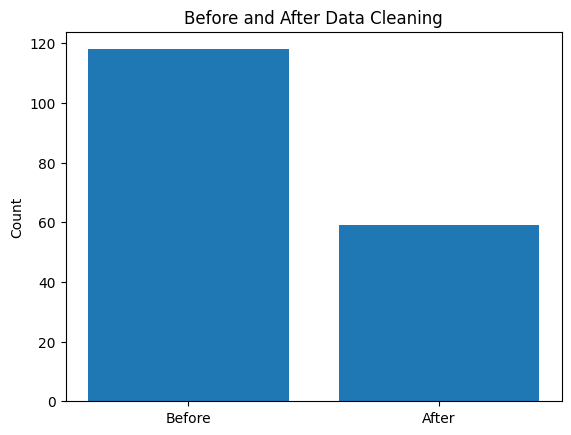

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

before_df = len(raw_df)
after_df = len(clean_df)

data = [before_df, after_df]

plt.bar(["Before", "After"], data)
plt.title("Before and After Data Cleaning")
plt.ylabel("Count")
plt.show()


349.0
349.0


/tmp/ipython-input-2950455074.py:35: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1['Original Price'], ax=ax[0])
/tmp/ipython-input-2950455074.py:38: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df2['Original Price'], ax=ax[1])


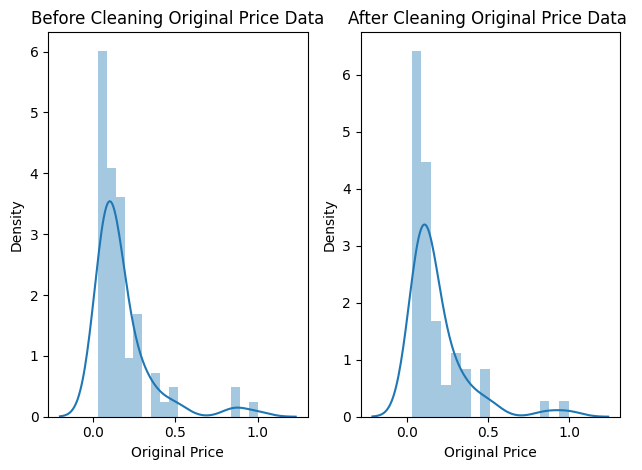

So, this is highlight 'Original Price' attribute after cleaning process (remove NaN)


In [ ]:
df1 = raw_df.copy()
df2 = clean_df.copy()

df1["Original Price"] = (
    df1["Original Price"]
    .astype(str)
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.replace("RM", "", regex=False)
    .str.replace("EUR", "", regex=False)
    .str.strip()
)

#convert original price str to integer
df1["Original Price"] = pd.to_numeric(df1["Original Price"], errors="coerce")


max_val = df1["Original Price"].max()

print(max_val)

#normalize price
df1['Original Price'] = df1['Original Price'] / max_val

max_val = df2["Original Price"].max()

print(max_val)

#normalize price
df2['Original Price'] = df2['Original Price'] / max_val

# 4. Plot using distplot
fig, ax = plt.subplots(1, 2)

sns.distplot(df1['Original Price'], ax=ax[0])
ax[0].set_title("Before Cleaning Original Price Data")

sns.distplot(df2['Original Price'], ax=ax[1])
ax[1].set_title("After Cleaning Original Price Data ")

plt.tight_layout()
plt.show()

print("So, this is highlight 'Original Price' attribute after cleaning process (remove NaN)")

In [ ]:

clean_df["Discount %"] = (
    (clean_df["Original Price"] - clean_df["Price"]) / clean_df["Original Price"]
) * 100

clean_df["Discount %"] = clean_df["Discount %"].round(2)
clean_df = clean_df[clean_df["Discount %"] > 0]   # keep valid discounts only

clean_df.head(5)

,Product Name,Price,Original Price,Brand,Rating,Number of Reviews,Delivery Info,Product URL,Discount %
0,JBL Vibe Beam,29.95,49.95,JBL,4.2,0.0,Jan 11 - 12,https://www.amazon.com/JBL-Vibe-Beam-Wireless-...,40.04
1,JBL Vibe Beam 2,39.95,64.95,JBL,4.2,0.0,Jan 7 - 8,https://www.amazon.com/JBL-Vibe-Beam-Cancellin...,38.49
2,"Soundcore by Anker P20i True Wireless Earbuds,...",19.99,39.99,SOUNDCORE,4.4,0.0,"Fri, Jan 9",https://www.amazon.com/Soundcore-Wireless-Blue...,50.01
3,occiam Sport Wireless Earbuds Bluetooth Headph...,17.99,38.99,OCCIAM,4.8,0.0,Top Reviewed for Battery life,https://www.amazon.com/occiam-Bluetooth-Headph...,53.86
4,"BERIBES Bluetooth Headphones Over Ear, 65H Pla...",19.99,28.99,BERIBES,4.5,0.0,Top Reviewed for Battery life,https://www.amazon.com/BERIBES-Bluetooth-Headp...,31.05


Are discounts usually small (5–10%) or aggressive (30–50%)?


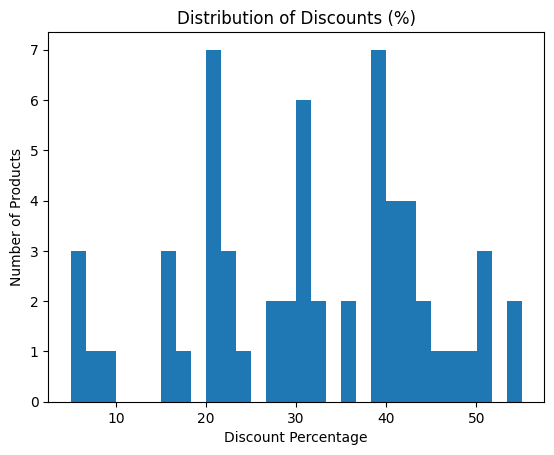

In [ ]:
#Visualization 1: Distribution of Discounts (Overall Strategy)
print("Are discounts usually small (5–10%) or aggressive (30–50%)?")
import matplotlib.pyplot as plt

plt.hist(clean_df["Discount %"], bins=30)
plt.title("Distribution of Discounts (%)")
plt.xlabel("Discount Percentage")
plt.ylabel("Number of Products")
plt.show()


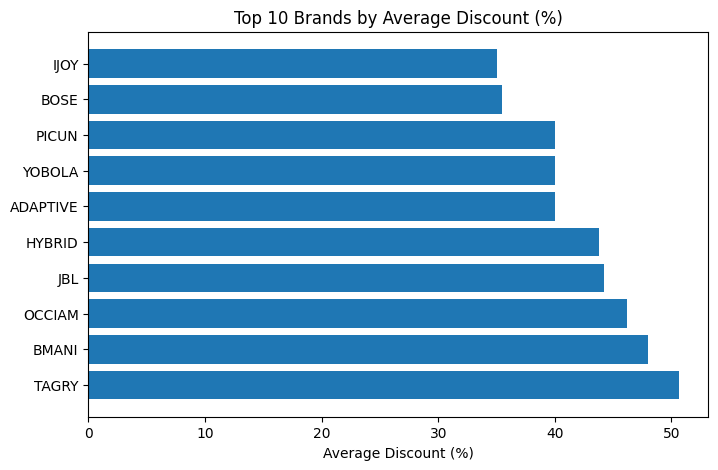

In [ ]:
#Visualization 2: Average Discount by Brand (Pricing Strategy)
brand_discount = (
    clean_df.groupby("Brand")["Discount %"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,5))
plt.barh(brand_discount.index, brand_discount.values)
plt.title("Top 10 Brands by Average Discount (%)")
plt.xlabel("Average Discount (%)")
plt.show()
